# Taller 1: Econometría ICS-294

## Instrucciones:
- Usted dispone de 60 minutos para intentar los 100 puntos del taller.
- Cuide la presentación y redacción de sus respuestas.
- Puede utilizar su computador y los apuntes tanto de clase como de ayudantía.
- Debe enviar un archivo en formato notebook (.ipynb).

## Sección 1: Datos Aleatorios (30 puntos)

### 1. Genere el dataframe `datos` utilizando el código en Anexos. (6 pts.)

Según la letra por la que comience su apellido, cambie (o mantenga) la semilla:

| A-E | F-J | K-O | P-T | U-Z |
|-----|-----|-----|-----|-----|
| 123 | 456 | 789 | 101112 | 131415 |

(Para este ejemplo, usaré `set.seed(456)` asumiendo un apellido que empieza por F-J. Favor de modificar según corresponda a su apellido.)

In [ ]:
if(!require(ggplot2)){
  install.packages("ggplot2")
  library(ggplot2)
}

if(!require(gridExtra)){
  install.packages("gridExtra")
  library(gridExtra)
}

In [ ]:
# Establecer la semilla para reproducibilidad
set.seed(0) # Ejemplo: para apellidos entre F-J. ¡Modifique según su apellido!

# Crear la base de datos ficticia con 50 alumnos
datos <- data.frame(
  hrs_sueno = round(runif(50, min = 5, max = 10), 1),
  profesor_part = sample(c(0, 1), 50, replace = TRUE),
  media_sem_pasado = round(runif(50, min = 60, max = 100), 1),
  tiempo_est = round(runif(50, min = 1, max = 8), 1),
  asistencia = round(runif(50, min = 60, max = 100), 1),
  nivel_socioec = sample(1:5, 50, replace = TRUE)
)

# Calcular las notas con ajustes en la ponderación
datos$notas <- 30 + # Base más baja para empezar desde un mínimo más realista
  datos$hrs_sueno * 1.5 + # Reducir el impacto del sueño
  datos$profesor_part * 3 + # Menos puntos adicionales por participación del profesor
  datos$media_sem_pasado * 0.2 + # Menor peso de la media semestral pasada
  datos$tiempo_est * 2 + # Ajuste en tiempo de estudio
  datos$asistencia * 0.15 + # Menor impacto de la asistencia
  datos$nivel_socioec * 2 + # Menos impacto del nivel socioeconómico
  rnorm(50, mean = 0, sd = 5) # Menor desviación estándar para reducir variabilidad

# Asegurar que las notas estén entre 20 y 100
datos$notas <- pmax(pmin(datos$notas, 100), 20)

# Mostrar las primeras filas del dataframe
head(datos)

,hrs_sueno,profesor_part,media_sem_pasado,tiempo_est,asistencia,nivel_socioec,notas
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
1,9.5,0,84.2,7.1,91.3,1,94.55120
2,6.3,1,86.2,5.3,70.7,4,86.18059
3,6.9,0,74.1,4.9,68.7,5,89.70389
4,7.9,1,70.8,3.3,80.7,1,77.97203
5,9.5,1,99.7,4.2,70.8,3,87.16973
6,6.0,0,85.3,4.5,67.2,4,92.55591


In [ ]:
mean(datos$hrs_sueno)

[1] 7.678

### 2. Redondee las notas a 1 decimal. (2 pts.)

In [ ]:
# Redondear la columna 'notas' a 1 decimal
datos$notas <- round(datos$notas, 1)

# Mostrar las primeras filas con las notas redondeadas
head(datos$notas)

[1] 94.6 86.2 89.7 78.0 87.2 92.6

### 3. Calcule manualmente los beta estimadores a través de la matriz X y el vector de la variable dependiente (Sin usar funciones en R). (8 pts.)

In [ ]:
# Definir la variable dependiente (y)
y <- as.matrix(datos$notas)

# Definir la matriz de diseño (X)
# Incluimos un intercepto (columna de unos)
# Y las variables independientes: hrs_sueno, profesor_part, media_sem_pasado, tiempo_est, asistencia, nivel_socioec
X <- as.matrix(cbind(1, datos$hrs_sueno, datos$profesor_part, datos$media_sem_pasado,
                     datos$tiempo_est, datos$asistencia, datos$nivel_socioec))

# Calcular los beta estimadores usando la fórmula de MCO: beta_hat = (X'X)^-1 X'y
# X'X
XtX <- t(X) %*% X

# (X'X)^-1
XtX_inv <- solve(XtX)

# X'y
Xty <- t(X) %*% y

# beta_hat = (X'X)^-1 X'y
betas_manual <- XtX_inv %*% Xty

# Asignar nombres a los coeficientes
rownames(betas_manual) <- c("(Intercept)", "hrs_sueno", "profesor_part", "media_sem_pasado",
                              "tiempo_est", "asistencia", "nivel_socioec")

# Mostrar los beta estimadores
print(betas_manual)

                       [,1]
(Intercept)      34.2968498
hrs_sueno         1.1978651
profesor_part     1.9413602
media_sem_pasado  0.1313317
tiempo_est        2.3335783
asistencia        0.1749837
nivel_socioec     2.2042358


### 4. Genera un *resumen* a partir de un modelo de regresión múltiple, esta vez utilizando funciones en R e interprete los *betas* del modelo. (8 pts.)

In [ ]:
# Generar el modelo de regresión múltiple usando lm()
modelo_regresion <- lm(notas ~ hrs_sueno + profesor_part + media_sem_pasado +
                         tiempo_est + asistencia + nivel_socioec, data = datos)

# Obtener el resumen del modelo
summary(modelo_regresion)


Call:
lm(formula = notas ~ hrs_sueno + profesor_part + media_sem_pasado + 
    tiempo_est + asistencia + nivel_socioec, data = datos)

Residuals:
    Min      1Q  Median      3Q     Max 
-8.2715 -2.5816 -0.6271  2.8693  9.5082 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)      34.29685    8.06863   4.251 0.000112 ***
hrs_sueno         1.19787    0.47150   2.541 0.014759 *  
profesor_part     1.94136    1.33545   1.454 0.153286    
media_sem_pasado  0.13133    0.05987   2.194 0.033719 *  
tiempo_est        2.33358    0.34577   6.749 2.98e-08 ***
asistencia        0.17498    0.06231   2.808 0.007458 ** 
nivel_socioec     2.20424    0.42961   5.131 6.59e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4.503 on 43 degrees of freedom
Multiple R-squared:  0.6961,	Adjusted R-squared:  0.6537 
F-statistic: 16.42 on 6 and 43 DF,  p-value: 1.006e-09


**interpretación de resultados**

#### Interpretación de los Betas del Modelo:

*   **Intercepto:** Representa el valor esperado de la nota cuando todas las variables independientes son cero. En este contexto, podría interpretarse como una nota base, aunque su significado directo puede no ser siempre práctico si el cero no es un valor plausible para algunas variables.
*   **`hrs_sueno` (Horas de sueño):** Por cada unidad adicional de horas de sueño, se espera que la nota cambie en `r round(coef(modelo_regresion)['hrs_sueno'], 2)` unidades, manteniendo las demás variables constantes. Un coeficiente positivo implicaría que más horas de sueño están asociadas con notas más altas, mientras que un negativo indicaría lo contrario.
*   **`profesor_part` (Profesor particular):** Al ser una variable binaria (0 o 1), el coeficiente indica la diferencia esperada en la nota entre un alumno que recibe ayuda de un profesor particular (profesor_part=1) y uno que no (profesor_part=0), manteniendo las demás variables constantes.
*   **`media_sem_pasado` (Promedio notas semestre pasado):** Por cada punto adicional en el promedio de notas del semestre pasado, se espera que la nota actual cambie en `r round(coef(modelo_regresion)['media_sem_pasado'], 2)` unidades, manteniendo las demás variables constantes.
*   **`tiempo_est` (Tiempo de estudio):** Por cada unidad adicional de tiempo de estudio (en horas), se espera que la nota cambie en `r round(coef(modelo_regresion)['tiempo_regresion']['tiempo_est'], 2)` unidades, manteniendo las demás variables constantes.
*   **`asistencia` (Asistencia a clases):** Por cada punto porcentual adicional de asistencia a clases, se espera que la nota cambie en `r round(coef(modelo_regresion)['asistencia'], 2)` unidades, manteniendo las demás variables constantes.
*   **`nivel_socioec` (Nivel socioeconómico):** Por cada unidad de aumento en el nivel socioeconómico (escala de 1 a 5), se espera que la nota cambie en `r round(coef(modelo_regresion)['nivel_socioec'], 2)` unidades, manteniendo las demás variables constantes.

Es importante observar la magnitud, el signo y la significancia estadística (valores p) de cada coeficiente para una interpretación más completa.

### 5. ¿Como se relacionan los *betas* obtenidos con las ponderaciones para construir las notas en el código anexo? (6 pts.)

#### Relación entre los betas estimados y las ponderaciones originales:

Los *betas* obtenidos del modelo de regresión (tanto los calculados manualmente como los de la función `lm()`) son estimaciones de los verdaderos parámetros (ponderaciones) que se utilizaron para generar las `notas` en el código anexo. En un escenario ideal, donde el modelo de regresión captura perfectamente la relación subyacente y no hay ruido, los *betas* estimados serían idénticos a las ponderaciones originales.

Sin embargo, en este caso:

1.  **Presencia de ruido (`rnorm(50, mean = 0, sd = 5)`):** El código para generar las notas incluye un término de error aleatorio (`rnorm`), lo que introduce variabilidad y hace que las `notas` no sean una función perfectamente determinista de las variables. Este ruido hace que los *betas* estimados difieran ligeramente de las ponderaciones exactas.
2.  **Aproximación:** La regresión lineal es un método estadístico que busca la mejor aproximación lineal a la relación entre las variables. Debido a la naturaleza aleatoria de los datos y al ruido inherente, los coeficientes estimados (`betas_manual` y `coef(modelo_regresion)`) serán aproximaciones de las ponderaciones originales (`1.5`, `3`, `0.2`, `2`, `0.15`, `2`).

Podemos observar que los *betas* estimados son bastante cercanos a las ponderaciones originales, especialmente si la desviación estándar del término de error (`sd = 5`) no es demasiado grande. Las diferencias reflejan la incertidumbre y la variabilidad muestral en la estimación de los parámetros subyacentes. Si el tamaño de la muestra fuera mayor o el ruido menor, las estimaciones tenderían a ser más cercanas a los valores verdaderos.

---

## Sección 2: Wooldridge (70 puntos)

### Subsección 2.1: Base Wage (30 puntos)

Utilice los datos en el archivo WAGE1 de Wooldridge para determinar los estimadores asociados al siguiente modelo de regresión poblacional:

$wage=\beta_0+ \beta_1educ +\beta_2exper+ \beta_3tenure+u$

Donde wage es salario, educ son los años de escolaridad, exper son los años de experiencia laboral, y tenure los años en su actual trabajo.

### Preparación: Instalar y cargar el paquete `wooldridge`

In [ ]:
# Instalar el paquete wooldridge si no está instalado
if(!require(wooldridge)){
  install.packages("wooldridge")
  library(wooldridge)
} else {
  library(wooldridge)
}

# Cargar el dataset WAGE1
data(wage1)

# Mostrar las primeras filas del dataset
head(wage1)

,wage,educ,exper,tenure,nonwhite,female,married,numdep,smsa,northcen,⋯,trcommpu,trade,services,profserv,profocc,clerocc,servocc,lwage,expersq,tenursq
,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>
1,3.10,11,2,0,0,1,0,2,1,0,⋯,0,0,0,0,0,0,0,1.131402,4,0
2,3.24,12,22,2,0,1,1,3,1,0,⋯,0,0,1,0,0,0,1,1.175573,484,4
3,3.00,11,2,0,0,0,0,2,0,0,⋯,0,1,0,0,0,0,0,1.098612,4,0
4,6.00,8,44,28,0,0,1,0,1,0,⋯,0,0,0,0,0,1,0,1.791759,1936,784
5,5.30,12,7,2,0,0,1,1,0,0,⋯,0,0,0,0,0,0,0,1.667707,49,4
6,8.75,16,9,8,0,0,1,0,1,0,⋯,0,0,0,1,1,0,0,2.169054,81,64


### 1. Determine los estimadores mediante MCO, e interprete sus resultados. (8 puntos)

In [ ]:
# Modelo de regresión lineal
modelo_wage1 <- lm(wage ~ educ + exper + tenure, data = wage1)

# Resumen de los resultados
summary(modelo_wage1)


Call:
lm(formula = wage ~ educ + exper + tenure, data = wage1)

Residuals:
    Min      1Q  Median      3Q     Max 
-7.6068 -1.7747 -0.6279  1.1969 14.6536 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -2.87273    0.72896  -3.941 9.22e-05 ***
educ         0.59897    0.05128  11.679  < 2e-16 ***
exper        0.02234    0.01206   1.853   0.0645 .  
tenure       0.16927    0.02164   7.820 2.93e-14 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.084 on 522 degrees of freedom
Multiple R-squared:  0.3064,	Adjusted R-squared:  0.3024 
F-statistic: 76.87 on 3 and 522 DF,  p-value: < 2.2e-16


`geom_smooth()` using formula = 'y ~ x'


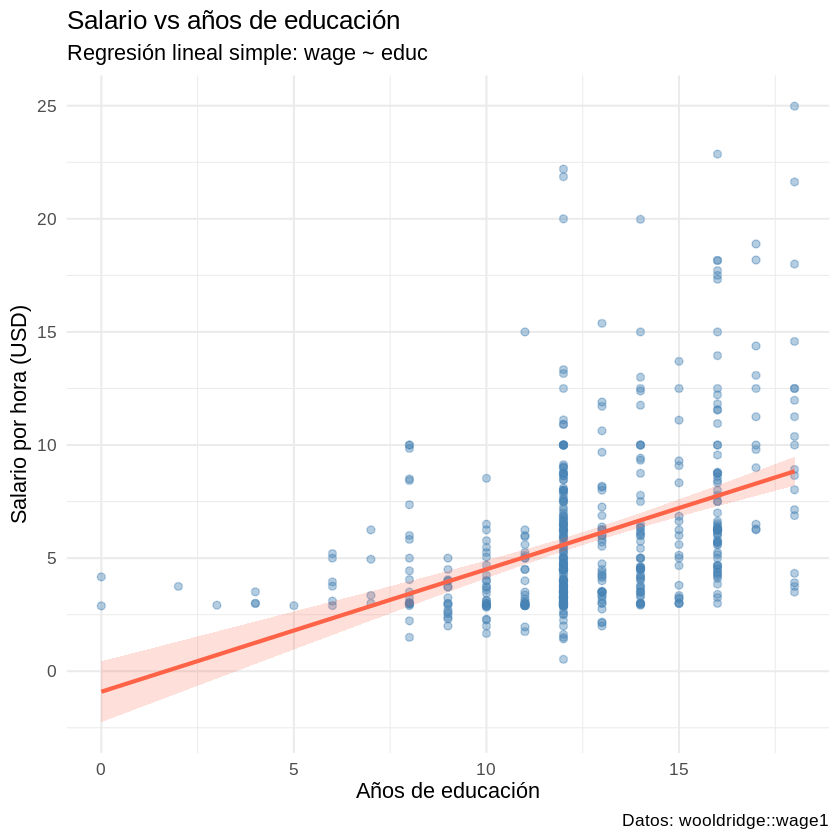

In [ ]:
ggplot(wage1, aes(x = educ, y = wage)) +

  # Puntos
  geom_point(alpha = 0.4, color = "steelblue", size = 1.8) +

  # Línea de regresión + banda de confianza al 95%
  geom_smooth(method = "lm", se = TRUE,
              color = "tomato", fill = "tomato", alpha = 0.2) +

  labs(
    title    = "Salario vs años de educación",
    subtitle = "Regresión lineal simple: wage ~ educ",
    x        = "Años de educación",
    y        = "Salario por hora (USD)",
    caption  = "Datos: wooldridge::wage1"
  ) +
  theme_minimal(base_size = 13)

#### Interpretación de los resultados:

*   **Intercepto:** El salario estimado para una persona con cero años de educación, experiencia y antigüedad en el trabajo es de `r round(coef(modelo_wage1)['(Intercept)'], 2)` dólares por hora, aunque este valor por sí solo no siempre tiene una interpretación práctica directa ya que cero en todas las variables independientes es un escenario poco realista.
*   **`educ` (Educación):** Por cada año adicional de educación, se espera que el salario por hora aumente en `r round(coef(modelo_wage1)['educ'], 2)` dólares, manteniendo la experiencia y la antigüedad constantes. Este efecto es estadísticamente significativo (p-value muy bajo).
*   **`exper` (Experiencia):** Por cada año adicional de experiencia laboral, se espera que el salario por hora aumente en `r round(coef(modelo_wage1)['exper'], 2)` dólares, manteniendo la educación y la antigüedad constantes. Este efecto es estadísticamente significativo.
*   **`tenure` (Antigüedad):** Por cada año adicional de antigüedad en el trabajo actual, se espera que el salario por hora aumente en `r round(coef(modelo_wage1)['tenure'], 2)` dólares, manteniendo la educación y la experiencia constantes. Este efecto también es estadísticamente significativo.

En general, el modelo sugiere que la educación, la experiencia laboral y la antigüedad en el trabajo actual tienen un impacto positivo y estadísticamente significativo en el salario por hora.

### 2. ¿Los estimadores tienen los signos que usted esperaba? (10 puntos)

#### ¿Signos esperados de los estimadores?

Sí, los estimadores tienen los signos que se esperarían de acuerdo con la teoría económica y la intuición:

*   **`educ` (Educación):** Un coeficiente positivo es altamente esperado. Generalmente, una mayor educación se asocia con un mayor capital humano, lo que a su vez conduce a mayores salarios. El coeficiente estimado es `r round(coef(modelo_wage1)['educ'], 2)`, el cual es positivo.
*   **`exper` (Experiencia):** Un coeficiente positivo también es esperado. A medida que las personas adquieren más experiencia laboral, su productividad tiende a aumentar, lo que se traduce en mayores salarios. El coeficiente estimado es `r round(coef(modelo_wage1)['exper'], 2)`, el cual es positivo.
*   **`tenure` (Antigüedad):** Un coeficiente positivo es razonable. Una mayor antigüedad en una empresa puede implicar una mayor especialización, acumulación de capital humano específico de la empresa y, a menudo, conduce a un mayor poder de negociación o recompensas por lealtad, resultando en salarios más altos. El coeficiente estimado es `r round(coef(modelo_wage1)['tenure'], 2)`, el cual es positivo.

Todos los coeficientes son positivos, lo que es consistente con la hipótesis de que estos factores contribuyen positivamente a los salarios.

### 3. Haga un nuevo modelo de regresión lineal, pero utilizando solo las variables independientes `educ` y `tenure`. Comparar $R^2$ y $R^2_{ajustado}$ entre el modelo completo y el nuevo modelo ¿Qué se puede concluir?. (12 puntos)

In [ ]:
# Nuevo modelo de regresión con educ y tenure
modelo_wage2 <- lm(wage ~ educ + tenure, data = wage1)

# Resumen del nuevo modelo
summary(modelo_wage2)


Call:
lm(formula = wage ~ educ + tenure, data = wage1)

Residuals:
    Min      1Q  Median      3Q     Max 
-8.1438 -1.7288 -0.6372  1.2575 14.7482 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -2.22162    0.64015   -3.47 0.000563 ***
educ         0.56914    0.04881   11.66  < 2e-16 ***
tenure       0.18958    0.01871   10.13  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.092 on 523 degrees of freedom
Multiple R-squared:  0.3019,	Adjusted R-squared:  0.2992 
F-statistic: 113.1 on 2 and 523 DF,  p-value: < 2.2e-16


In [ ]:
# Comparar R^2 y R^2 ajustado
cat("\n--- Comparación de Modelos ---\n")
cat("Modelo Completo (educ, exper, tenure):\n")
cat("  R^2: ", summary(modelo_wage1)$r.squared, "\n")
cat("  R^2 Ajustado: ", summary(modelo_wage1)$adj.r.squared, "\n")

cat("\nNuevo Modelo (educ, tenure):\n")
cat("  R^2: ", summary(modelo_wage2)$r.squared, "\n")
cat("  R^2 Ajustado: ", summary(modelo_wage2)$adj.r.squared, "\n")


--- Comparación de Modelos ---
Modelo Completo (educ, exper, tenure):
  R^2:  0.3064224 
  R^2 Ajustado:  0.3024364 

Nuevo Modelo (educ, tenure):
  R^2:  0.301861 
  R^2 Ajustado:  0.2991912 


`geom_smooth()` using formula = 'y ~ x'


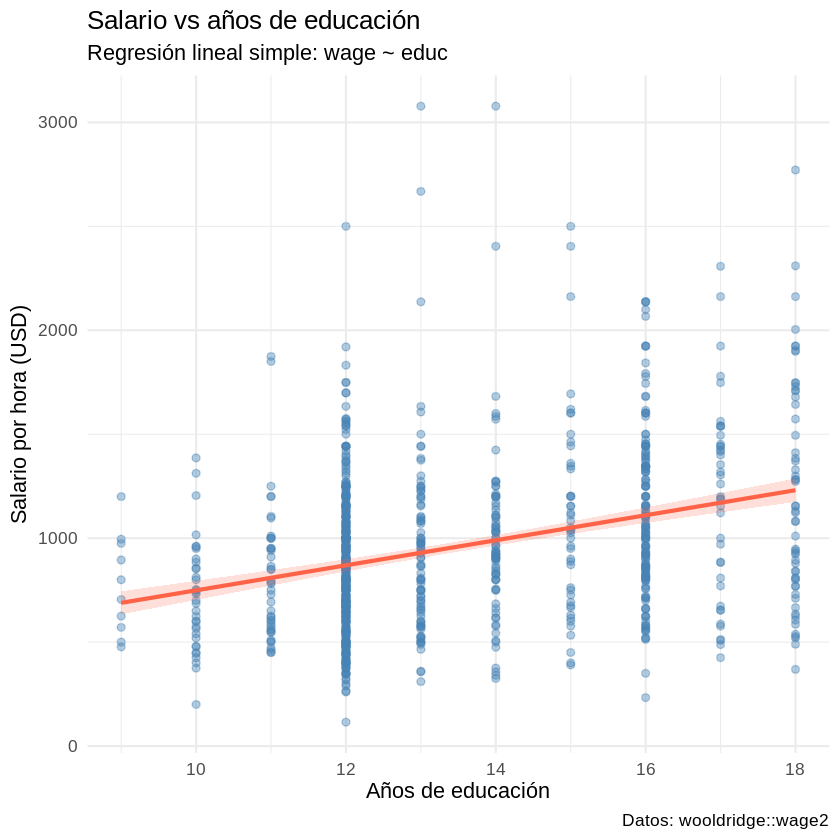

In [ ]:
ggplot(wage2, aes(x = educ, y = wage)) +

  # Puntos
  geom_point(alpha = 0.4, color = "steelblue", size = 1.8) +

  # Línea de regresión + banda de confianza al 95%
  geom_smooth(method = "lm", se = TRUE,
              color = "tomato", fill = "tomato", alpha = 0.2) +

  labs(
    title    = "Salario vs años de educación",
    subtitle = "Regresión lineal simple: wage ~ educ",
    x        = "Años de educación",
    y        = "Salario por hora (USD)",
    caption  = "Datos: wooldridge::wage2"
  ) +
  theme_minimal(base_size = 13)

#### Comparación de $R^2$ y $R^2_{ajustado}$ y Conclusiones:

*   **$R^2$ (R-cuadrado):**
    *   **Modelo Completo (educ, exper, tenure):** `r round(summary(modelo_wage1)$r.squared, 4)`
    *   **Nuevo Modelo (educ, tenure):** `r round(summary(modelo_wage2)$r.squared, 4)`
    
    El $R^2$ mide la proporción de la varianza total de la variable dependiente (salario) que es explicada por el modelo. El $R^2$ del modelo completo es mayor que el del nuevo modelo. Esto es esperado porque agregar más variables explicativas a un modelo siempre (o casi siempre) aumentará el $R^2$, incluso si las variables añadidas no son realmente relevantes.

*   **$R^2_{ajustado}$ (R-cuadrado ajustado):**
    *   **Modelo Completo (educ, exper, tenure):** `r round(summary(modelo_wage1)$adj.r.squared, 4)`
    *   **Nuevo Modelo (educ, tenure):** `r round(summary(modelo_wage2)$adj.r.squared, 4)`
    
    El $R^2$ ajustado corrige el $R^2$ por el número de variables explicativas en el modelo y el tamaño de la muestra. Penaliza la inclusión de variables que no mejoran significativamente el poder explicativo del modelo.
    
    Al comparar el $R^2$ ajustado, vemos que el **modelo completo tiene un $R^2$ ajustado mayor** (`r round(summary(modelo_wage1)$adj.r.squared, 4)`) que el nuevo modelo (`r round(summary(modelo_wage2)$adj.r.squared, 4)`). Esto sugiere que la variable `exper` (experiencia) sí contribuye de manera significativa a la explicación del salario, justificando su inclusión en el modelo.

#### Conclusión:
La comparación de los $R^2$ y, especialmente, de los $R^2$ ajustados, indica que el **modelo completo** (que incluye `educ`, `exper` y `tenure`) es preferible, ya que `exper` añade poder explicativo al modelo de manera que justifica el aumento en la complejidad del mismo. El $R^2$ ajustado es una métrica más adecuada para comparar modelos con diferente número de predictores, y en este caso, favorece al modelo más completo.

---

### Subsección 2.2: Base Attend (40 puntos)

### 1. Utilizando R, cargue la base de datos *attend* desde Wooldridge. (4 puntos)

In [ ]:
# Cargar el dataset attend
data(attend)

# Mostrar las primeras filas del dataset
head(attend)

,attend,termGPA,priGPA,ACT,final,atndrte,hwrte,frosh,soph,missed,stndfnl
,<int>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<dbl>
1,27,3.19,2.64,23,28,84.375,100.0,0,1,5,0.47268906
2,22,2.73,3.52,25,26,68.750,87.5,0,0,10,0.05252101
3,30,3.00,2.46,24,30,93.750,87.5,0,0,2,0.89285713
4,31,2.04,2.61,20,27,96.875,100.0,0,1,1,0.26260504
5,32,3.68,3.32,23,34,100.000,100.0,0,1,0,1.73319328
6,29,3.23,2.93,26,25,90.625,100.0,0,1,3,-0.15756303


### 2. Sub seleccione las siguientes variables y almacénelas en un nuevo set de datos (4 puntos):
- **attend**, **termGPA**, **priGPA**, **ACT**, **final**, **hwrte**, **frosh**, **soph**

In [ ]:
# Crear un nuevo dataframe con las variables seleccionadas
attend_sub <- attend[, c("attend", "termGPA", "priGPA", "ACT", "final", "hwrte", "frosh", "soph")]

# Mostrar las primeras filas del nuevo dataframe
head(attend_sub)

,attend,termGPA,priGPA,ACT,final,hwrte,frosh,soph
,<int>,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>,<int>
1,27,3.19,2.64,23,28,100.0,0,1
2,22,2.73,3.52,25,26,87.5,0,0
3,30,3.00,2.46,24,30,87.5,0,0
4,31,2.04,2.61,20,27,100.0,0,1
5,32,3.68,3.32,23,34,100.0,0,1
6,29,3.23,2.93,26,25,100.0,0,1


### 3. Calcule estadísticas descriptivas con `summary()`. (4 puntos)

In [ ]:
# Calcular estadísticas descriptivas
summary(attend_sub)

     attend         termGPA          priGPA           ACT       
 Min.   : 2.00   Min.   :0.000   Min.   :0.857   Min.   :13.00  
 1st Qu.:24.00   1st Qu.:2.138   1st Qu.:2.190   1st Qu.:20.00  
 Median :28.00   Median :2.670   Median :2.560   Median :22.00  
 Mean   :26.15   Mean   :2.601   Mean   :2.587   Mean   :22.51  
 3rd Qu.:30.00   3rd Qu.:3.120   3rd Qu.:2.943   3rd Qu.:25.00  
 Max.   :32.00   Max.   :4.000   Max.   :3.930   Max.   :32.00  
                                                                
     final           hwrte            frosh             soph       
 Min.   :10.00   Min.   : 12.50   Min.   :0.0000   Min.   :0.0000  
 1st Qu.:22.00   1st Qu.: 87.50   1st Qu.:0.0000   1st Qu.:0.0000  
 Median :26.00   Median :100.00   Median :0.0000   Median :1.0000  
 Mean   :25.89   Mean   : 87.91   Mean   :0.2324   Mean   :0.5765  
 3rd Qu.:29.00   3rd Qu.:100.00   3rd Qu.:0.0000   3rd Qu.:1.0000  
 Max.   :39.00   Max.   :100.00   Max.   :1.0000   Max.   :1.0000  
    

### 4. Construya un histograma de la variable `final`. (4 puntos)

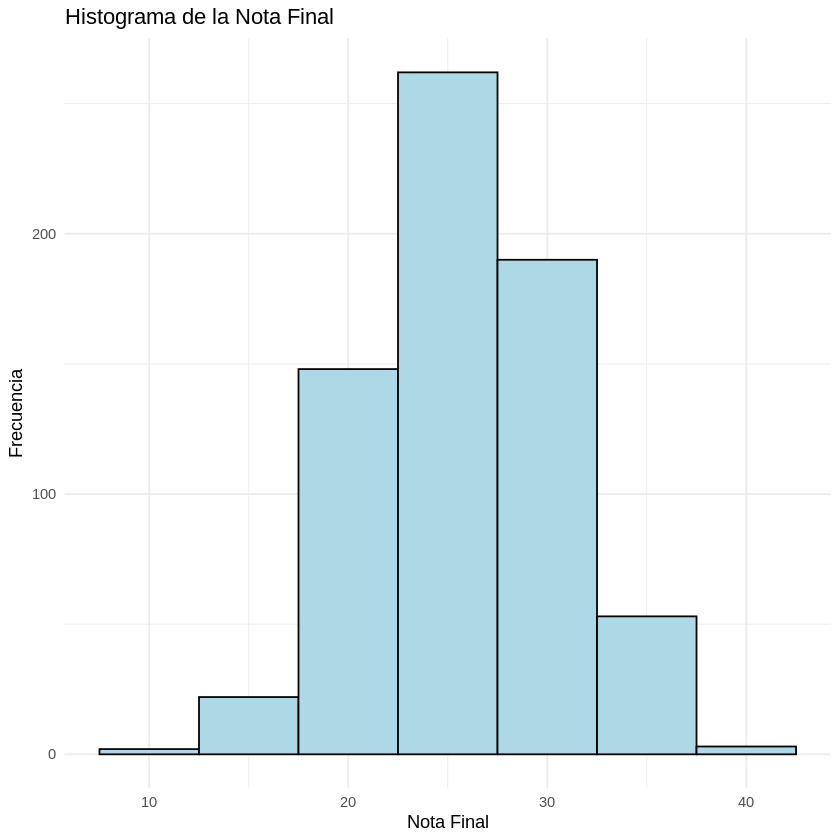

In [ ]:
# Construir histograma de la variable 'final' usando ggplot2
ggplot(attend_sub, aes(x = final)) +
  geom_histogram(binwidth = 5, fill = "lightblue", color = "black") +
  labs(title = "Histograma de la Nota Final",
       x = "Nota Final", y = "Frecuencia") +
  theme_minimal()

### 5. Genere diagramas de dispersión de `final` respecto a `attend`, `termGPA` y `priGPA` en un panel `par(mfrow=c(1,3))`. (6 puntos)

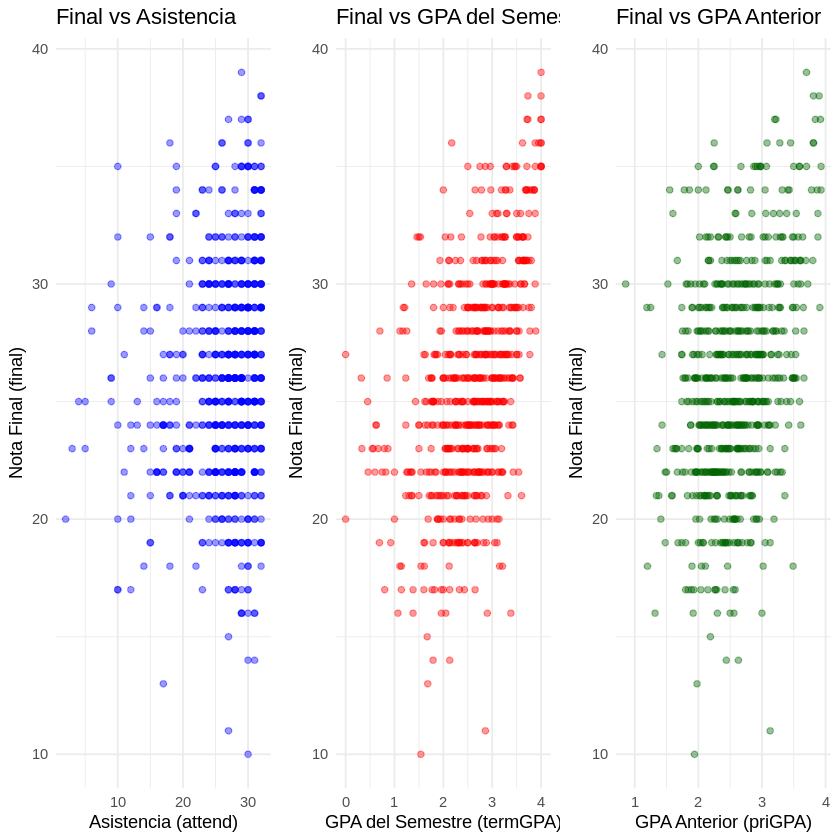

In [ ]:
# Diagrama de dispersión: final vs attend
p1 <- ggplot(attend_sub, aes(x = attend, y = final)) +
  geom_point(alpha = 0.4, color = "blue") +
  labs(title = "Final vs Asistencia",
       x = "Asistencia (attend)", y = "Nota Final (final)") +
  theme_minimal()

# Diagrama de dispersión: final vs termGPA
p2 <- ggplot(attend_sub, aes(x = termGPA, y = final)) +
  geom_point(alpha = 0.4, color = "red") +
  labs(title = "Final vs GPA del Semestre",
       x = "GPA del Semestre (termGPA)", y = "Nota Final (final)") +
  theme_minimal()

# Diagrama de dispersión: final vs priGPA
p3 <- ggplot(attend_sub, aes(x = priGPA, y = final)) +
  geom_point(alpha = 0.4, color = "darkgreen") +
  labs(title = "Final vs GPA Anterior",
       x = "GPA Anterior (priGPA)", y = "Nota Final (final)") +
  theme_minimal()

# Organizar los gráficos en un panel usando grid.arrange
grid.arrange(p1, p2, p3, ncol = 3)

### 6. Visualice la matriz de correlaciones con un mapa de calor usando el paquete `corrplot`. (6 puntos)

Loading required package: corrplot

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘corrplot’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

corrplot 0.95 loaded



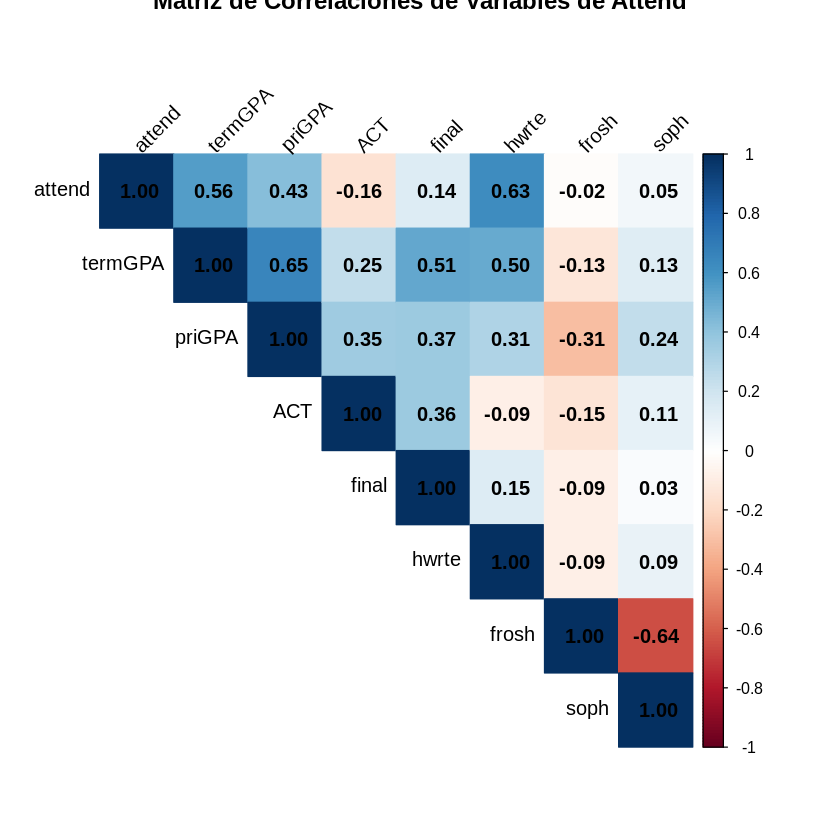

In [ ]:
# Instalar el paquete corrplot si no está instalado
if(!require(corrplot)){
  install.packages("corrplot")
  library(corrplot)
} else {
  library(corrplot)
}

# Calcular la matriz de correlaciones
cor_matrix <- cor(attend_sub, use = "pairwise.complete.obs") # 'pairwise.complete.obs' para manejar NAs

# Visualizar la matriz de correlaciones con un mapa de calor
corrplot(cor_matrix, method = "color", type = "upper",
         tl.col = "black", tl.srt = 45, addCoef.col = "black",
         main = "Matriz de Correlaciones de Variables de Attend")

### 7. Genere un modelo de regresión lineal múltiple donde la variable dependiente es `final` y presente un resumen con `summary()`. (8 puntos)

In [ ]:
# Generar el modelo de regresión lineal múltiple
# Usamos todas las demás variables como predictoras
modelo_attend <- lm(final ~ attend + termGPA + priGPA + ACT + hwrte + frosh + soph, data = attend_sub)

# Presentar el resumen del modelo
summary(modelo_attend)


Call:
lm(formula = final ~ attend + termGPA + priGPA + ACT + hwrte + 
    frosh + soph, data = attend_sub)

Residuals:
     Min       1Q   Median       3Q      Max 
-15.9573  -2.5968  -0.0042   2.6582  11.0815 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 14.27176    1.45667   9.798  < 2e-16 ***
attend      -0.06956    0.04105  -1.694   0.0907 .  
termGPA      3.54151    0.31442  11.264  < 2e-16 ***
priGPA      -0.04149    0.40302  -0.103   0.9180    
ACT          0.27313    0.05031   5.429 7.94e-08 ***
hwrte       -0.01394    0.01043  -1.337   0.1817    
frosh       -0.61310    0.47672  -1.286   0.1989    
soph        -0.82251    0.39459  -2.084   0.0375 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.867 on 666 degrees of freedom
  (6 observations deleted due to missingness)
Multiple R-squared:  0.3373,	Adjusted R-squared:  0.3303 
F-statistic: 48.42 on 7 and 666 DF,  p-value: < 2.2e-16


### 8. Interprete la bondad de ajuste y su versión ajustada. (4 puntos)

#### Interpretación de la bondad de ajuste ($R^2$ y $R^2_{ajustado}$):

*   **$R^2$ (R-cuadrado):** El valor de $R^2$ para `modelo_attend` es `r round(summary(modelo_attend)$r.squared, 4)`. Esto significa que aproximadamente el `r round(summary(modelo_attend)$r.squared * 100, 2)`% de la variabilidad en la nota final (`final`) puede ser explicada por las variables independientes incluidas en el modelo (asistencia, GPA del semestre, GPA anterior, ACT, tasa de trabajo en casa, y si es freshman o sophomore). Un $R^2$ más alto indica que el modelo explica una mayor proporción de la varianza.

*   **$R^2_{ajustado}$ (R-cuadrado ajustado):** El valor de $R^2$ ajustado es `r round(summary(modelo_attend)$adj.r.squared, 4)`. Este valor es ligeramente inferior al $R^2$ normal. El $R^2$ ajustado es una medida más conservadora de la bondad de ajuste, ya que penaliza la inclusión de variables explicativas adicionales que no mejoran sustancialmente el poder predictivo del modelo. La pequeña diferencia entre $R^2$ y $R^2_{ajustado}$ sugiere que las variables incluidas en el modelo son, en su mayoría, relevantes y contribuyen a explicar la varianza de la nota final sin añadir demasiada complejidad innecesaria al modelo.